Total bugs: 453
Filtered bugs: 215
File: 66517915e09.c, Lines: (24, 24), Bugs: 10
File: 1b487ea8a69.c, Lines: (14, 14), Bugs: 2
File: 6252547b8a7.c, Lines: (25, 25), Bugs: 3
File: bc0ffc0e971.c, Lines: (40, 40), Bugs: 3
File: 0f8f8094d28.c, Lines: (39, 39), Bugs: 7
File: 66517915e09.c, Lines: (16, 16), Bugs: 12
File: 6252547b8a7.c, Lines: (12, 12), Bugs: 5
File: bc0ffc0e971.c, Lines: (43, 43), Bugs: 3
File: 76baeebf7df.c, Lines: (41, 41), Bugs: 2
File: 199501f2a00.c, Lines: (21, 21), Bugs: 2
File: 8c4377dd635.c, Lines: (21, 21), Bugs: 2
File: 061fd0a353e.c, Lines: (20, 20), Bugs: 5
File: 5275b1e49f6.c, Lines: (18, 18), Bugs: 6
File: b62bd7b261b.c, Lines: (14, 14), Bugs: 3
File: 30e053248da.c, Lines: (31, 31), Bugs: 5
File: 8c4377dd635.c, Lines: (13, 13), Bugs: 8
File: 35ae2e259e4.c, Lines: (12, 12), Bugs: 3
File: 7acf6cd80b2.c, Lines: (8, 8), Bugs: 3
File: 581635e28f1.c, Lines: (7, 7), Bugs: 2
File: 6e2b75740be.c, Lines: (67, 67), Bugs: 1
File: e30bfedce4d.c, Lines: (24, 24), Bugs: 4
F

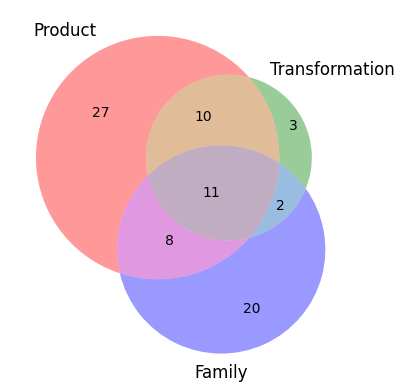

In [3]:
import os
import json
from csv import DictReader

bugs_directory = "../../results/ESEM_26/bug_reports"
csv_path = "../../results/ESEM_26/classifications.csv"

bugs = {}
classification = {}

with open(csv_path, 'r') as csv_file:
    lines = csv_file.readlines()
    csv_reader = DictReader(lines)
    for row in csv_reader:
        classification[row['id']] = row['Agreed Classification']

for filename in os.listdir(bugs_directory):
    if filename.endswith(".json") and "#" not in filename:
        with open(os.path.join(bugs_directory, filename), 'r') as json_file:
            bug_data = json.load(json_file)
            bug_id = bug_data['id']
            bugs[bug_id] = bug_data

for bug_id, bug_data in bugs.items():
    bug_data['classification'] = classification[bug_id]
    if 'err' in bug_data:
        bug_data['tool'] = 'typechef'
        bug_data['strategy'] = 'family'
    elif bug_data['originalAlarm']['alarmType'].isupper():
        bug_data['tool'] = 'infer'
    else:
        bug_data['tool'] = 'clang'


filtered_bugs = list(filter(lambda k: "TRUE" in k[1]['classification'], bugs.items()))
print(f"Total bugs: {len(bugs)}")
print(f"Filtered bugs: {len(filtered_bugs)}")

# Group bugs by line number and file
grouped_bugs = {}
venn = {}
for bug_id, bug_data in filtered_bugs:
    if bug_data['strategy'] == 'product':
        line = bug_data['originalAlarm']['line']
        lines = [line, line]
        file = os.path.basename(bug_data['originalAlarm']['fileLocation'])
    elif bug_data['strategy'] == 'transformation':
        lines = bug_data['lineInputFile']
        file = os.path.basename(bug_data['originalFile'])
    else: # family
        line = bug_data['line_number']
        lines = [line, line]
        file = os.path.basename(bug_data['input_file'])
    key = (file, tuple(lines))
    if key not in grouped_bugs:
        grouped_bugs[key] = []
    grouped_bugs[key].append(bug_data)
    if bug_data['strategy'] not in venn:
        venn[bug_data['strategy']] = set()
    venn[bug_data['strategy']].add(key)

# Print the grouped bugs
for key, bugs in grouped_bugs.items():
    print(f"File: {key[0]}, Lines: {key[1]}, Bugs: {len(bugs)}")

# Create the venn diagram
import matplotlib.pyplot as plt
from matplotlib_venn import venn3
venn3(subsets=(venn.get('product', set()), venn.get('transformation', set()), venn.get('family', set())), set_labels=('Product', 'Transformation', 'Family'))
plt.show()